**Multi-Factor Return Forecasting für Microsoft (2010–2019)**

In diesem Projekt modelliere ich die 5-Tage-Vorwärts-Renditen der Microsoft-Aktie anhand verschiedener Aktien-, Währungs- und Makro-Indikatoren.

Ziel: Wie unterschiedliche finanzielle Faktoren kurzfristige Kursbewegungen beeinflussen und wie verschiedene Modellansätze im Vergleich abschneiden.

Zum Einsatz kommen unter anderem:

1. Lineare Regression (Basis-Modell)

2. Decision Tree Regressor (nichtlineares Modell)

3. LSTM-Neuronales Netzwerk (sequenzbasiertes Deep-Learning-Modell)

Dieses Notebook umfasst:

1. Datenextraktion aus Yahoo Finance und FRED

2. Feature Engineering auf Basis mehrerer Assets und Finanzindikatoren

3. Explorative Datenanalyse (Korrelationsmatrix, Scatterplots, saisonale Dekomposition)

4. Training und Evaluation der Modelle mittels MSE (Train vs. Test)

5. Visualisierung von tatsächlichen vs. prognostizierten Renditeverläufen

6. Interpretation der Ergebnisse und Diskussion der Grenzen von Finanzprognosen

**Schritt 1: Importieren der Notwendigen Bibliotheken**

In diesem Abschnitt lade ich alle Python-Bibliotheken, die für Datenextraktion, Datenaufbereitung, Visualisierung und Modellierung benötigt werden. Dazu gehören u. a. *Pandas* für Datenverarbeitung, *NumPy* für mathematische Operationen, *Matplotlib/Seaborn* für Visualisierungen, *Statsmodels* für statistische Analysen und *TensorFlow/Keras* für die Deep-Learning-Modelle.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import datetime

import pandas_datareader.data as web
import yfinance as yf

from matplotlib import pyplot
from pandas.plotting import scatter_matrix
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

**Schritt 2: Datenquellen und Datenextraktion**

Für die Analyse verwende ich drei Gruppen von Finanzdaten:

**Aktienkurse**: Microsoft, IBM und Alphabet (Quelle: Yahoo Finance)

**Wechselkurse**: USD/JPY und USD/GBP (Quelle: FRED)

**Marktindizes**: S&P 500, Dow Jones und VIX (Quelle: Yahoo Finance)

Der Analysezeitraum umfasst 2010 bis 2019, um eine breite Marktphase mit verschiedenen Regimes (Bull/Bear, Volatilität) abzudecken.

In [2]:
stk_tickers = ["MSFT", "IBM", "GOOGL"] #stock ticker
ccy_tickers = ["DEXJPUS", "DEXUSUK"] #currency
idx_tickers = ["^GSPC", "^DJI", "^VIX"] #Indecies
idx_tickers_name = ["SP500", "DJIA", "VIXCLS"]

start_date = datetime.datetime(2010, 1, 1)
end_date = datetime.datetime(2019, 12, 31)

stk_data = yf.download(stk_tickers, start_date, end_date)
ccy_data = web.get_data_fred(ccy_tickers, start_date, end_date)
idx_data = yf.download(idx_tickers, start_date, end_date)

print(stk_data.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed

Price           Close                             High                        \
Ticker          GOOGL        IBM       MSFT      GOOGL        IBM       MSFT   
Date                                                                           
2010-01-04  15.566815  72.881500  23.130051  15.635367  73.167633  23.242151   
2010-01-05  15.498264  72.001076  23.137520  15.593889  72.551333  23.242148   
2010-01-06  15.107574  71.533363  22.995535  15.544711  72.353247  23.227209   
2010-01-07  14.755875  71.285751  22.756386  15.150789  71.670929  22.943220   
2010-01-08  14.952589  72.001076  22.913328  14.983138  72.039591  23.077742   

Price             Low                             Open                        \
Ticker          GOOGL        IBM       MSFT      GOOGL        IBM       MSFT   
Date                                                                           
2010-01-04  15.504475  72.001092  22.861009  15.571783  72.182674  22.883430   
2010-01-05  15.437413  71.588383  22.89

**Schritt 3: Feature Engineering und Zielvariable**

In diesem Schritt definiere ich die Zielvariable (Y) als 5-Tage-Vorwärts-Log-Rendite von MSFT. Zusätzlich erstelle ich die Eingangsvariablen (X) aus Renditen anderer Aktien, Wechselkursen, Marktindizes sowie lag-basierten MSFT-Features. Anschließend führe ich alles zu einem gemeinsamen Datensatz zusammen und entferne fehlende Werte.



In [3]:
return_period = 5 #5 business day period returns

#Pre-process data by defining Y and X series
Y = np.log(stk_data.loc[:, ("Close", "MSFT")]).diff(return_period).shift(-return_period)
Y.name = Y.name[-1]+"_pred"

X1 = np.log(stk_data.loc[:, ("Close", ("GOOGL", "IBM"))]).diff(return_period)
X1.columns = X1.columns.droplevel()
X2 = np.log(ccy_data).diff(return_period)
X3 = np.log(idx_data.loc[:, ("Close", ("^GSPC", "^DJI", "^VIX"))]).diff(return_period)
X3.columns = idx_tickers_name

X4 = pd.concat([np.log(stk_data.loc[:, ("Close", "MSFT")]).diff(i) for i in [return_period, return_period*3, return_period*6, return_period*12]], axis=1).dropna()
X4.columns = ["MSFT_DT", "MSFT_3DT", "MSFT_6DT", "MSFT_12DT"]

X = pd.concat([X1, X2, X3, X4], axis=1)

dataset = pd.concat([Y, X], axis=1).dropna().iloc[::return_period, :]
Y = dataset.loc[:, Y.name]
X = dataset.loc[:, X.columns]

pd.set_option("display.precision", 3)
dataset.describe()

print(dataset.head())

            MSFT_pred      GOOGL    IBM    DEXJPUS  DEXUSUK  SP500       DJIA  \
2010-03-31      0.021  1.741e-02 -0.002  1.630e-02    0.018  0.001  1.888e-03   
2010-04-08      0.031  6.523e-04 -0.005 -7.166e-03   -0.001  0.014  6.467e-03   
2010-04-15      0.017  4.784e-02  0.025 -1.289e-03    0.013  0.021  1.971e-02   
2010-04-22     -0.013 -8.451e-02 -0.014 -3.225e-04   -0.006 -0.002 -9.229e-04   
2010-04-29     -0.067 -2.791e-02  0.010  1.229e-02   -0.004 -0.002  2.962e-03   

            VIXCLS  MSFT_DT  MSFT_3DT  MSFT_6DT  MSFT_12DT  
2010-03-31   0.002   -0.012     0.011     0.024     -0.050  
2010-04-08  -0.065    0.021     0.010     0.044     -0.007  
2010-04-15  -0.036    0.031     0.040     0.081     -0.003  
2010-04-22   0.036    0.017     0.069     0.080      0.067  
2010-04-29   0.113   -0.013     0.035     0.045      0.090  


**Schritt 4: Explorative Datenanalyse**

**Schritt 4.1: Verteilungen der Variablen**

Zunächst werden Histogramme aller Variablen dargestellt, um einen Überblick über Verteilungen, Schiefe und mögliche Ausreißer zu erhalten.

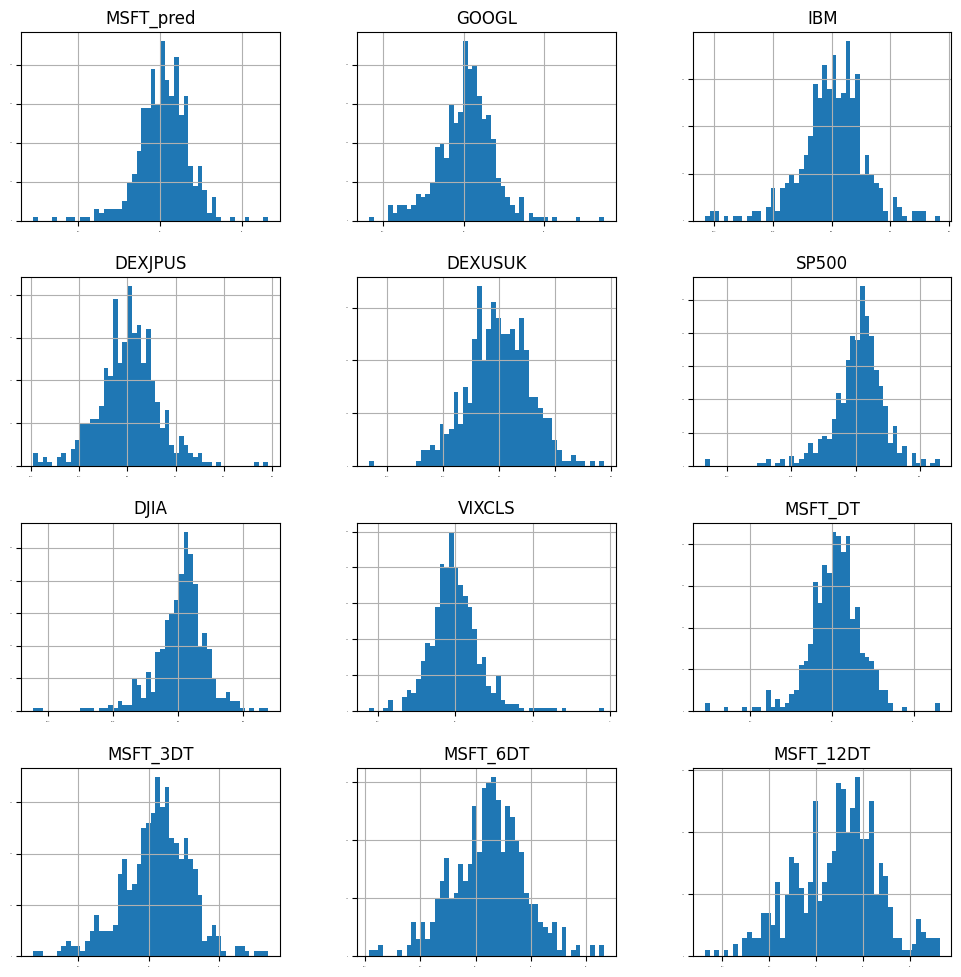

In [4]:
#visualize data
dataset.hist(bins=50, sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(12,12))
pyplot.show()

**Schritt 4.2: Korrelationsanalyse**

Als nächstes wird eine Korrelationsmatrix berechnet, um lineare Zusammenhänge zwischen Zielvariable und erklärenden Variablen sichtbar zu machen.

<Axes: title={'center': 'Correlation Matrix'}>

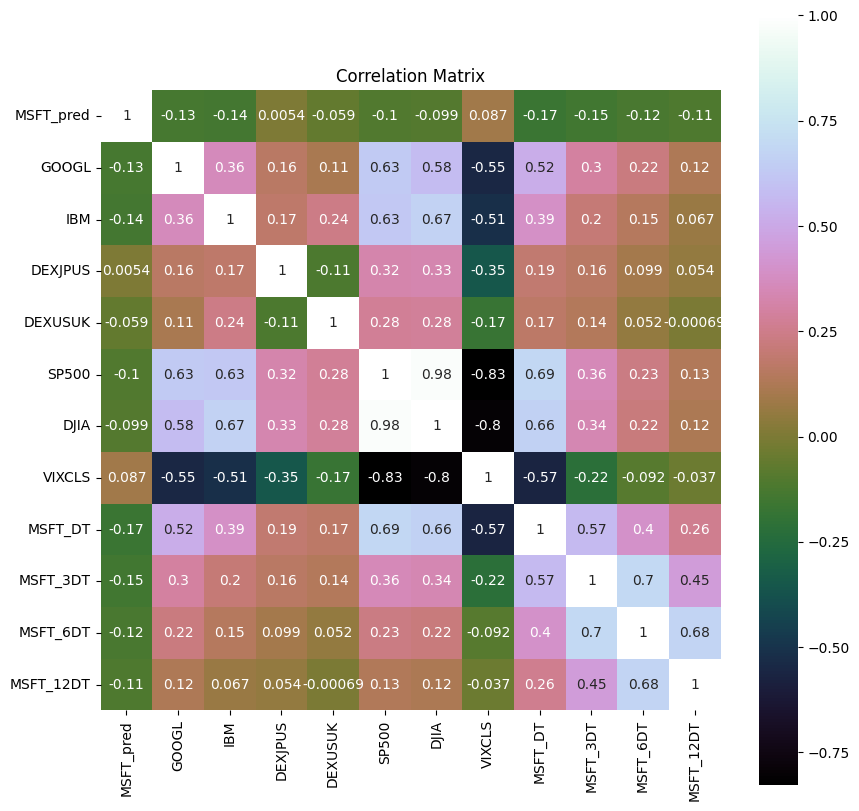

In [5]:
correlation = dataset.corr()
pyplot.figure(figsize=(10,10))
pyplot.title("Correlation Matrix")
sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap="cubehelix")

**Schritt 5: Saisonale Dekomposition der Zielvariable**

Zur besseren Einordnung der Zielvariable wird die Zeitreihe der 5-Tage-Vorwärts-Log-Renditen in Trend-, saisonale und Residual-Komponenten zerlegt. Das ermöglicht eine erste Einschätzung, ob systematische Muster oder Saisonalität vorliegen.

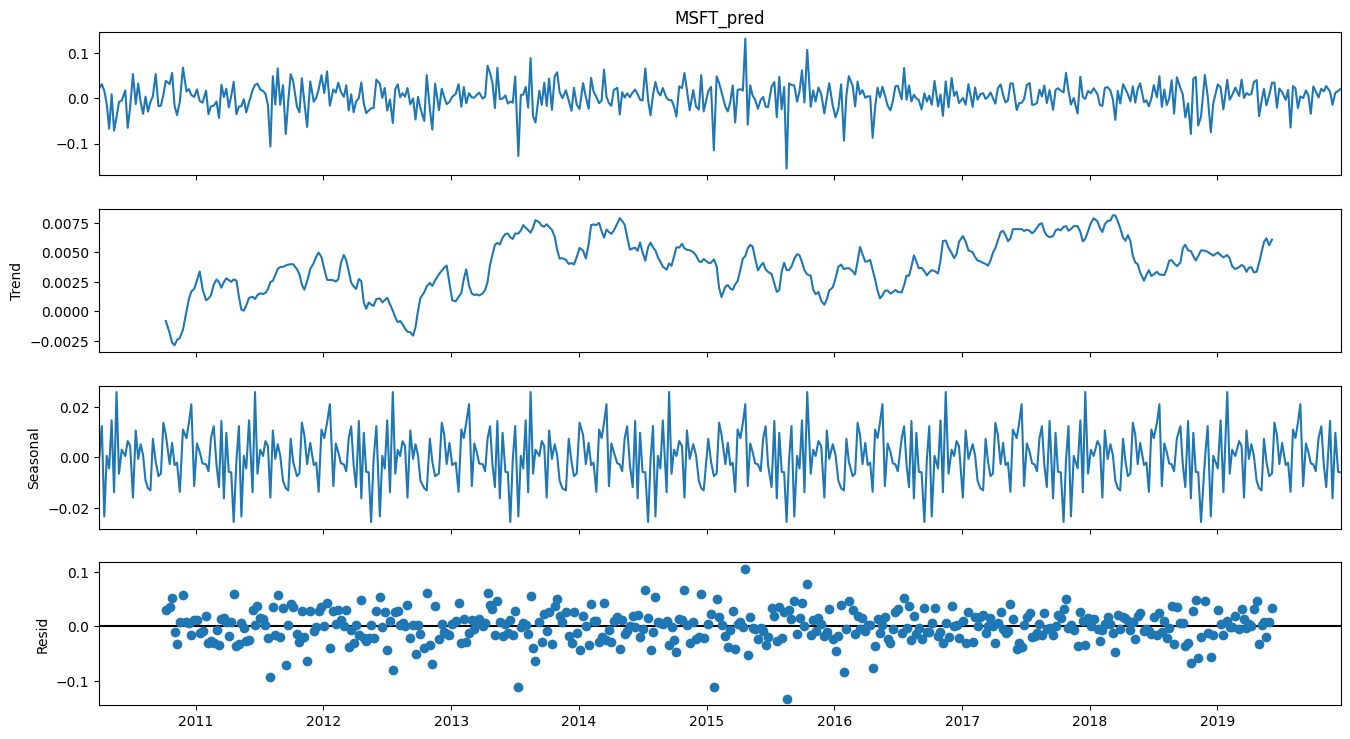

In [6]:
#Decomposition of time series
res = sm.tsa.seasonal_decompose(Y, period=52)
fig = res.plot()
fig.set_figheight(8)
fig.set_figwidth(15)
pyplot.show()

**Schritt 6: Aufteilung in Trainings- und Testdaten**

Zur Bewertung der Modellleistung werden die Daten in einen Trainings- und einen Testdatensatz aufgeteilt. Dabei wird bewusst ein zeitbasierter Split verwendet, um Datenleckage zu vermeiden und eine realistische Vorhersagesituation abzubilden.

In [7]:
#Train-Test split
test_size = 0.2
train_size = int(len(X) * (1-test_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(373, 11) (94, 11)
(373,) (94,)


**Schirtt 7: Modellvergleich - Klassische Regressionsmodelle**

**Schritt 7.1: Training und Evaluation der Modelle**

In diesem Schritt werden zwei klassische Regressionsmodelle (Lineare Regression und Decision Tree Regressor) trainiert und anhand des Mean Squared Error (MSE) auf Trainings- und Testdaten bewertet.



In [8]:
#Linear Regression & Decision Trees
models = []
models.append(("LR", LinearRegression()))
models.append(("DTR", DecisionTreeRegressor()))

names = []
test_results = []
train_results = []
for name, model in models:
    names.append(name)

    # Full Training period
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)

    # Test results
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

    msg = "%s: %f %f" % (name, train_result, test_result)
    print(msg)

LR: 0.000976 0.000755
DTR: 0.000000 0.001391


**Schritt 7.2: Vergleiche der Modellleistung**

Die folgende Abbildung vergleicht die Trainings- und Testfehler der Modelle und ermöglicht eine visuelle Einschätzung von Modellgüte und möglichem Overfitting.

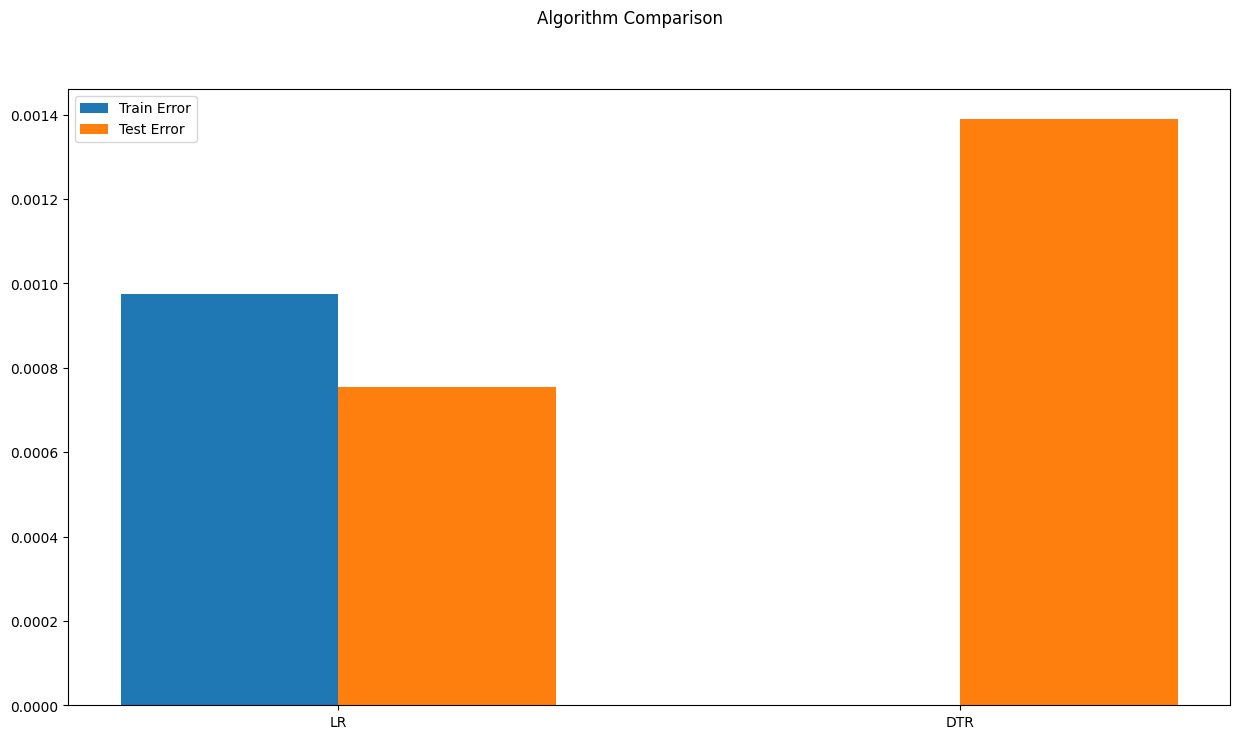

In [9]:
#Training & Test error
# Compare algorithms
fig = pyplot.figure()

ind = np.arange(len(names))  # the x locations for the groups
width = 0.35  # the width of the bars

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label="Train Error")
pyplot.bar(ind + width/2, test_results, width=width, label="Test Error")
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

**Schritt 8: Sequenzbasierte Modellierung mit LSTM**

**Schritt 8.1: Sequenzdaten vorbereiten**

Für das LSTM werden die Input-Features in kurze Sequenzen umgewandelt, sodass das Modell zeitliche Abhängigkeiten berücksichtigen kann. *seq_len* bestimmt dabei die Anzahl der Zeitschritte pro Sequenz.

In [10]:
seq_len = 2

Y_train_LSTM, Y_test_LSTM = np.array(Y_train)[seq_len-1:], np.array(Y_test)[seq_len-1:]
X_train_LSTM = np.zeros((X_train.shape[0]+1-seq_len, seq_len, X_train.shape[1]))
X_test_LSTM = np.zeros((X_test.shape[0]+1-seq_len, seq_len, X_test.shape[1]))

for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[i : i + X_train_LSTM.shape[0], :]

for i in range(seq_len):
    X_test_LSTM[:, i, :] = np.array(X_test)[i : i + X_test_LSTM.shape[0], :]

print(X_train_LSTM.shape, X_test_LSTM.shape)
print(Y_train_LSTM.shape, Y_test_LSTM.shape)

(372, 2, 11) (93, 2, 11)
(372,) (93,)


**Schritt 8.2: Modelarchitektur, Training und Validierung**

Anschließend wird ein einfaches LSTM-Modell trainiert. Als Loss-Function verwende ich MSE, optimiert mit dem Adam-Function.

In [12]:
#LSTM Network
model = Sequential()
model.add(LSTM(50, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))
model.add(Dense(1))
model.summary()

model.compile(loss="mse", optimizer="adam")
LSTMModel_fit = model.fit(X_train_LSTM, Y_train_LSTM, validation_data=(X_test_LSTM, Y_test_LSTM), epochs=330, batch_size=72, verbose=0, shuffle=False)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        12,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,451 (48.64 KB)

 Trainable params: 12,451 (48.64 KB)

 Non-trainable params: 0 (0.00 B)

**Schritt 8.3: Lernkurven (Training VS. Validation Loss)**

Die Lernkurven zeigen, ob der Fehler im Training sinkt und ob sich ein Unterschied zwischen Trainings- und Validierungsfehler *(Overfitting)* abzeichnet.

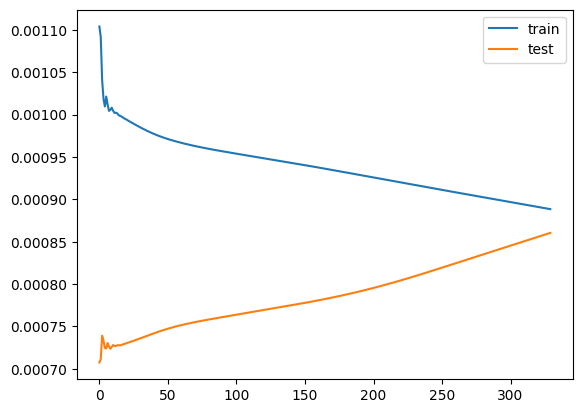

In [13]:
pyplot.plot(LSTMModel_fit.history["loss"], label="train")
pyplot.plot(LSTMModel_fit.history["val_loss"], label="test")
pyplot.legend()
pyplot.show()

**Schritt 9: Evaluation und Vergleich mit den Klassischen Modellen**

**Schritt 9.1: MSE berechnen + in Verleichsliste aufnehmen**

Abschließend berechne ich den MSE auf die Trainings- und Testdaten und ergänze die Ergebnisse in die Modellvergleichsübersicht.

In [17]:
error_Training_LSTM = mean_squared_error(Y_train_LSTM, model.predict(X_train_LSTM))
predicted = model.predict(X_test_LSTM)
error_Test_LSTM = mean_squared_error(Y_test_LSTM,predicted)

test_results.append(error_Test_LSTM)
train_results.append(error_Training_LSTM)

names.append("LSTM")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


**Schritt 9.2: Visueller Modelvergleich (Barplot)**

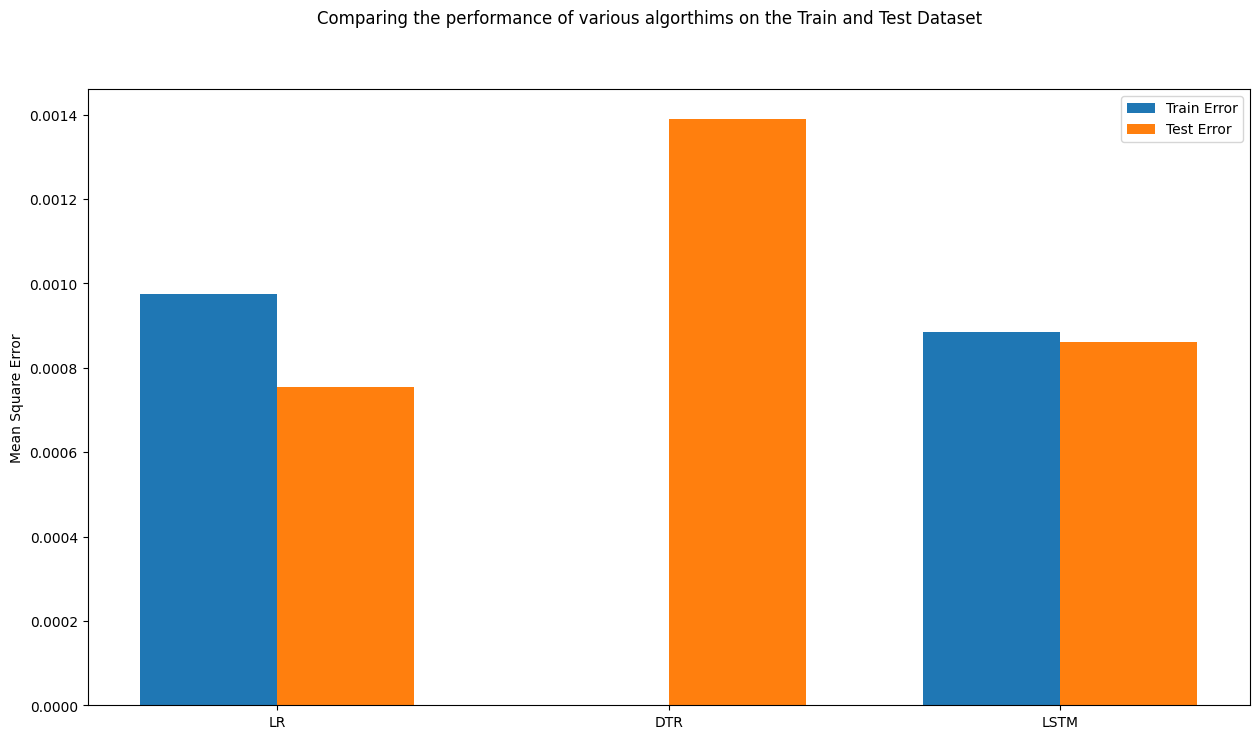

In [15]:
fig = pyplot.figure()

ind = np.arange(len(names))  
width = 0.35  

fig.suptitle("Comparing the performance of various algorthims on the Train and Test Dataset")
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label="Train Error")
pyplot.bar(ind + width/2, test_results, width=width, label="Test Error")
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.ylabel("Mean Square Error")
pyplot.show()

**Interpretation der Modellleistung (Train vs. Test Error)**

Die Abbildung vergleicht den Trainings- und Testfehler (MSE) der drei untersuchten Modelle: Lineare Regression, Decision Tree und LSTM.

Die Lineare Regression zeigt ähnliche Fehlerwerte auf Trainings- und Testdaten, was auf eine stabile, aber begrenzt flexible Modellstruktur hindeutet. Sie dient hier als sinnvoller Baseline-Ansatz.

Der Decision Tree weist auf einen extrem niedrigen Trainingsfehler, aber auf einen extrem hohen Testfehler auf. Dies deutet auf *Overfitting* hin: Das Modell passt sich stark an die Trainingsdaten an, generalisiert jedoch schlechter auf neue Daten.

Das LSTM-Modell erreicht einen vergleichbaren Testfehler als die Lineare Regression, jedoch ohne signifikanten Abstand. Dies verdeutlicht die bekannte hohe Rauschkomponente von Aktienrenditen, bei der auch komplexere Modelle nur begrenzte Vorteile liefern.

Insgesamt zeigt der Vergleich, dass komplexere Modelle nicht automatisch zu besseren Prognosen führen, insbesondere bei kurzfristigen Finanzrenditen.

**Schritt 10: Tatsächliche vs. prognositzierte Entwicklung**

Zum Abschluss vergleiche ich die kumulierte Entwicklung der tatsächlichen und prognostizierten Renditen, um die Vorhersage im „realistischen“ Verlauf zu beurteilen.

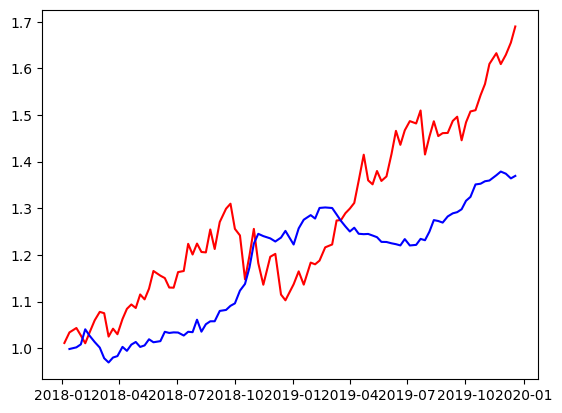

In [16]:
# Estimate accuracy on test set
predicted = pd.DataFrame(predicted)
predicted.index = Y_test.index[seq_len-1:]

pyplot.plot(np.exp(Y_test).cumprod(), "red")
pyplot.plot(np.exp(predicted).cumprod(), "blue")
pyplot.rcParams["figure.figsize"] = (8, 6)
pyplot.show()

**Vergleich von tatsächlicher und prognostizierter Entwicklung**

Die Abbildung zeigt den Vergleich zwischen der tatsächlichen (Rot) und der vom LSTM-Modell prognostizierten kumulierten Entwicklung (Blau) der Aktienrenditen im Testzeitraum.

Die prognostizierte Kurve folgt dem allgemeinen Verlauf der tatsächlichen Entwicklung nur eingeschränkt und weist deutliche Abweichungen auf.

Dies verdeutlicht die begrenzte Vorhersagbarkeit kurzfristiger Aktienrenditen, selbst bei Verwendung komplexerer, sequenzbasierter Modelle wie LSTMs.

Das Modell erfasst teilweise grobe Bewegungsrichtungen, ist jedoch nicht in der Lage, kurzfristige Schwankungen oder Wendepunkte zuverlässig vorherzusagen.

Das Ergebnis zeigt, dass Aktienrenditen durch einen hohen Zufalls- und Rauschanteil geprägt sind. In diesem Kontext dient das LSTM-Modell weniger als präzises Prognoseinstrument, sondern vielmehr als Analysewerkzeug zur Untersuchung zeitlicher Abhängigkeiten und zur Bewertung der Grenzen datengetriebener Vorhersagemethoden im Finanzbereich.